In [1]:
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from ml4deltabot.data_loader import load_single_file, create_datasets_from_dataframe
from ml4deltabot.model import build_nn_model, get_callbacks

In [2]:
# prepare inverse data (nm -> V)
# Input: current positions (x_out, z_out)
# Output: voltage windows that led to those positions

df_1V = load_single_file("1V_all_axis_1.txt", 1.0)
df_2V = load_single_file("2V_all_axis_1.txt", 2.0)
df_2p5V = load_single_file("2\'5V_all_axis_1.txt", 2.5)
df_3V = load_single_file("3V_all_axis_1.txt", 3.0)
df_4p5V = load_single_file("4\'5V_all_axis_2.txt", 4.5)
df_4V = load_single_file("4V_all_axis_2.txt", 4.0)

df_all = pd.concat([df_1V, df_2V, df_2p5V, df_3V, df_4p5V, df_4V], ignore_index=True)

train_ds, test_ds, input_dim, output_dim, X_scaler, y_scaler = \
    create_datasets_from_dataframe(
        df_all,
        random_split=True
    )

print(input_dim, output_dim)


Processing DataFrame...
  Processed: X=(2459998, 4), y=(2459998, 18)
  Features: [x_pos, y_pos, z_pos, voltage_level]
  Targets:  [9 voltage windows, 6 velocities, 3 accelerations]

  Voltage levels in dataset: [1.  2.  2.5 3.  4.  4.5]
    1.0V: 409998 samples (16.7%)
    2.0V: 410000 samples (16.7%)
    2.5V: 410000 samples (16.7%)
    3.0V: 410000 samples (16.7%)
    4.0V: 410000 samples (16.7%)
    4.5V: 410000 samples (16.7%)

Scaling data...
  Features scaled (positions + voltage_level)
  Targets scaled (voltages + derivatives)

Random split:
  Train: 1967998 samples (80%)
  Test:  492000 samples (20%)

TensorFlow datasets created:
  Batch size: 1024
  Train batches per epoch: 1922
  Test batches per epoch: 481

Model dimensions:
  Input:  4  (x_pos, y_pos, z_pos, voltage_level)
  Output: 18 (voltage windows + derivatives)

 Scalers available for inverse transform
4 18


In [3]:
model = build_nn_model(input_dim, output_dim, architecture='standard')

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=100,
    verbose=1
)

Epoch 1/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.7497 - mae: 0.4536 - val_loss: 0.8692 - val_mae: 0.4401
Epoch 2/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7177 - mae: 0.4347 - val_loss: 0.8613 - val_mae: 0.4342
Epoch 3/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7132 - mae: 0.4312 - val_loss: 0.8588 - val_mae: 0.4320
Epoch 4/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.7109 - mae: 0.4295 - val_loss: 0.8559 - val_mae: 0.4291
Epoch 5/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.7094 - mae: 0.4284 - val_loss: 0.8562 - val_mae: 0.4305
Epoch 6/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.7082 - mae: 0.4276 - val_loss: 0.8545 - val_mae: 0.4278
Epoch 7/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7072 - mae: 0.4268 - val_loss: 0.8523 - val_mae: 0.4266
Epoch 8/100
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7063 - mae: 0.4263 - val_loss: 0.8522 - val_mae: 0.4266
Epoch 9/100
1922/1922 ━━━━━━━━━━

In [6]:
import numpy as np
from sklearn.metrics import r2_score

y_pred_scaled = model.predict(test_ds, verbose=0)
y_test_batches = []
for _, y_batch in test_ds:
    y_test_batches.append(y_batch.numpy())
y_test_scaled = np.vstack(y_test_batches)

r2 = r2_score(y_test_scaled, y_pred_scaled)
print(f"\nR² Score: {r2:.4f}")


R² Score: 0.2734


In [8]:
deep_model = build_nn_model(input_dim, output_dim, architecture="deep")

deep_model_history = deep_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=250,
    callbacks=get_callbacks(patience=50, reduce_lr_patience=20),
    verbose=1
)

Epoch 1/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.7355 - mae: 0.4462 - val_loss: 0.8603 - val_mae: 0.4354 - learning_rate: 0.0010
Epoch 2/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.7104 - mae: 0.4300 - val_loss: 0.8527 - val_mae: 0.4285 - learning_rate: 0.0010
Epoch 3/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.7051 - mae: 0.4264 - val_loss: 0.8509 - val_mae: 0.4264 - learning_rate: 0.0010
Epoch 4/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.7020 - mae: 0.4243 - val_loss: 0.8476 - val_mae: 0.4243 - learning_rate: 0.0010
Epoch 5/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6993 - mae: 0.4225 - val_loss: 0.8436 - val_mae: 0.4221 - learning_rate: 0.0010
Epoch 6/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6971 - mae: 0.4212 - val_loss: 0.8420 - val_mae: 0.4208 - learning_rate: 0.0010
Epoch 7/250
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6951 - mae: 0.4200 - val_loss: 0.8412 - val_mae: 0.4201 - lea

In [9]:
y_pred_scaled = deep_model.predict(test_ds, verbose=0)
y_test_batches = []
for _, y_batch in test_ds:
    y_test_batches.append(y_batch.numpy())
y_test_scaled = np.vstack(y_test_batches)

r2 = r2_score(y_test_scaled, y_pred_scaled)
print(f"\nR² Score: {r2:.4f}")


R² Score: 0.3207


2026-03-03 15:45:46.505109: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
larger_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(output_dim)
])
larger_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

larger_model_history = larger_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=200,
    callbacks=get_callbacks(patience=50, reduce_lr_patience=20),
    verbose=1
)

y_pred_scaled = larger_model.predict(test_ds, verbose=0)
r2 = r2_score(y_test_scaled, y_pred_scaled)
print(f"\nR² Score: {r2:.4f}")

Epoch 1/200


/Users/namannimmo/miniconda3/envs/lp/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.7254 - mae: 0.4398 - val_loss: 0.8536 - val_mae: 0.4291 - learning_rate: 0.0010
Epoch 2/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.7035 - mae: 0.4254 - val_loss: 0.8461 - val_mae: 0.4268 - learning_rate: 0.0010
Epoch 3/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.6963 - mae: 0.4211 - val_loss: 0.8402 - val_mae: 0.4205 - learning_rate: 0.0010
Epoch 4/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6910 - mae: 0.4179 - val_loss: 0.8345 - val_mae: 0.4167 - learning_rate: 0.0010
Epoch 5/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6862 - mae: 0.4152 - val_loss: 0.8306 - val_mae: 0.4152 - learning_rate: 0.0010
Epoch 6/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6819 - mae: 0.4129 - val_loss: 0.8273 - val_mae: 0.4128 - learning_rate: 0.0010
Epoch 7/200
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6778 - mae: 0.4106 - val_loss: 0.8250 - val_mae: 0.4118 - learning_rat

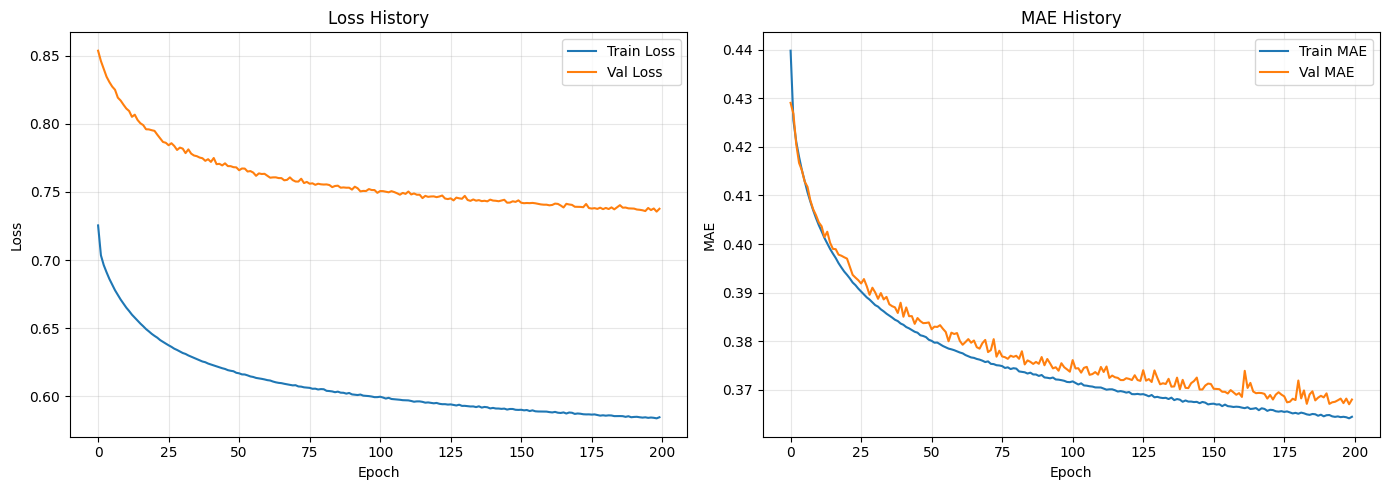

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(larger_model_history.history['loss'], label='Train Loss')
axes[0].plot(larger_model_history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(larger_model_history.history['mae'], label='Train MAE')
axes[1].plot(larger_model_history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE History')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# continue training the larger modelw with more epochs
larger_model_history_continued = larger_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=400,
    initial_epoch=200,
    callbacks=get_callbacks(patience=100, reduce_lr_patience=30),
    verbose=1
)

y_pred_scaled = larger_model.predict(test_ds, verbose=0)
r2_continued = r2_score(y_test_scaled, y_pred_scaled)
print(f"\nR² after more training: {r2_continued:.4f}")

Epoch 201/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.5839 - mae: 0.3642 - val_loss: 0.7380 - val_mae: 0.3675 - learning_rate: 0.0010
Epoch 202/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.5842 - mae: 0.3643 - val_loss: 0.7360 - val_mae: 0.3675 - learning_rate: 0.0010
Epoch 203/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.5835 - mae: 0.3640 - val_loss: 0.7371 - val_mae: 0.3681 - learning_rate: 0.0010
Epoch 204/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.5839 - mae: 0.3641 - val_loss: 0.7363 - val_mae: 0.3679 - learning_rate: 0.0010
Epoch 205/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.5835 - mae: 0.3640 - val_loss: 0.7359 - val_mae: 0.3670 - learning_rate: 0.0010
Epoch 206/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.5832 - mae: 0.3638 - val_loss: 0.7363 - val_mae: 0.3670 - learning_rate: 0.0010
Epoch 207/400
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.5836 - mae: 0.3640 - val_loss: 0.7349 - val_